In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.axes3d import Axes3D
from mpl_toolkits.mplot3d.proj3d import proj_transform

plt.rcParams.update({"text.usetex": True, "mathtext.fontset": "dejavuserif"})

In [2]:
class Arrow3D(FancyArrowPatch):

    def __init__(self, x, y, z, dx, dy, dz, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._xyz = (x, y, z)
        self._dxdydz = (dx, dy, dz)

    def draw(self, renderer):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        x1, y1, z1 = self._xyz
        dx, dy, dz = self._dxdydz
        x2, y2, z2 = (x1 + dx, y1 + dy, z1 + dz)

        xs, ys, zs = proj_transform((x1, x2), (y1, y2), (z1, z2), self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))

        return np.min(zs)


def _arrow3D(ax, x, y, z, dx, dy, dz, *args, **kwargs):
    """Add an 3d arrow to an `Axes3D` instance."""

    arrow = Arrow3D(x, y, z, dx, dy, dz, *args, **kwargs)
    ax.add_artist(arrow)


setattr(Axes3D, "arrow3D", _arrow3D)

In [3]:
xlim = 5
ulim = 5

# consensus manifold
us = np.linspace(-ulim, ulim, 10)
xs = np.linspace(-xlim, xlim, 10)
U, Xi = np.meshgrid(us, xs)
Xj = Xi


# stable branches
def f(x, p):
    return p * np.tanh(p * np.tanh(x)) - x


def forks(p):
    root = 0.0
    try:
        root = root_scalar(f, args=(p,), bracket=[1e-6, xlim], method="bisect").root
    except ValueError:
        pass
    return root

us = np.linspace(1, ulim, 1000)
prong = np.array([forks(u) for u in us])

# --- translucent cylinder -----------------------------------------------
R = 2.0
L = 7
center = np.array([1.0, 0.0, 0.0])          # (u, xi, xj)
axis = np.array([0.0, -1.0, 1.0])
axis = axis / np.linalg.norm(axis)

# build orthonormal vectors perpendicular to axis
tmp = np.array([1.0,0.0,0.0])
if np.abs(np.dot(tmp,axis)) > 0.9:
    tmp = np.array([0.0,1.0,0.0])

e1 = np.cross(axis,tmp)
e1 /= np.linalg.norm(e1)

e2 = np.cross(axis,e1)
e2 /= np.linalg.norm(e2)

# cylinder parameterization
theta = np.linspace(0,2*np.pi,80)
s = np.linspace(-L,L,50)

Theta,S = np.meshgrid(theta,s)

X = center[0] + S*axis[0] + R*np.cos(Theta)*e1[0] + R*np.sin(Theta)*e2[0]
Y = center[1] + S*axis[1] + R*np.cos(Theta)*e1[1] + R*np.sin(Theta)*e2[1]
Z = center[2] + S*axis[2] + R*np.cos(Theta)*e1[2] + R*np.sin(Theta)*e2[2]

# --- cross-section circle at center -------------------------------------
th = np.linspace(0,2*np.pi,400)
circle = center[:,None] + R*np.cos(th)[None,:]*e1[:,None] + R*np.sin(th)[None,:]*e2[:,None]

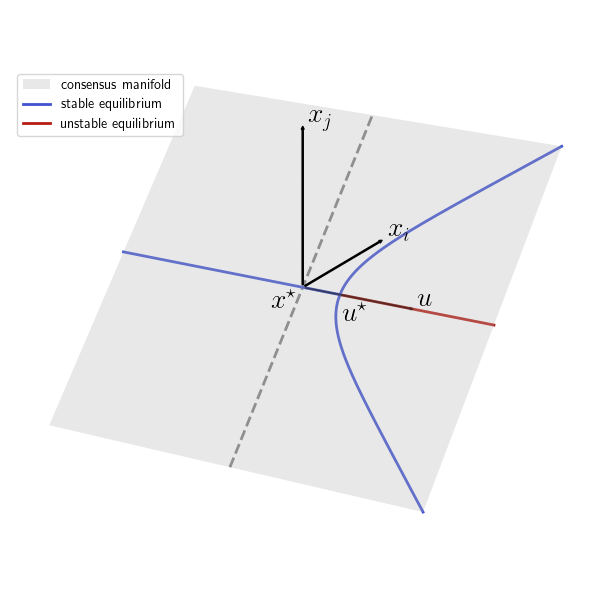

In [4]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot([0, 0], [-xlim, xlim], [-xlim, xlim], color="black", alpha=0.5, lw=2, ls="--")
# ax.plot([0, 0], [-2*xlim, 2*xlim], [0, 0], color="black", alpha=0.5, lw=2, ls="--")
# ax.plot([0, 0], [0, 0], [-1.5*xlim, 1.5*xlim], color="black", alpha=0.5, lw=2, ls="--")

ax.plot_surface(U, Xi, Xj, alpha=0.3, color="#cacaca", label="consensus manifold")
ax.plot([-ulim, 1], [0, 0], [0, 0], color="#4053d3", lw=2, label="stable equilibrium")
ax.plot([1, ulim], [0, 0], [0, 0], color="#b51d14", lw=2, label="unstable equilibrium")
ax.plot(us, +prong, +prong, color="#4053d3", lw=2)
ax.plot(us, -prong, -prong, color="#4053d3", lw=2)

ax.text(-.6,-.7,-.7, r"$x^\star$", fontsize=20, color="black")
ax.text(1.2,-.4,-.1, r"$u^\star$", fontsize=20, color="black", va="top", ha="left")

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.set_visible(False)
    axis.line.set_color((0, 0, 0, 0))
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set(xlim=(-ulim, ulim), ylim=(-xlim, xlim), zlim=(-xlim, xlim))

ax.arrow3D(0,0,0, 3,0,0, mutation_scale=4, ec="black", fc="black", alpha=0.3)
ax.text(3.0,0.1,0.1, r"$u$", fontsize=20)
ax.arrow3D(0,0,0, 0,6,0, mutation_scale=4, ec="black", fc="black", alpha=1.0)
ax.text(0.1,6.0,0.1, r"$x_i$", fontsize=20)
ax.arrow3D(0,0,0, 0,0,6, mutation_scale=4, ec="black", fc="black", alpha=1.0)
ax.text(0.1,0.1,6.0, r"$x_j$", fontsize=20)

ax.legend(loc='upper left', bbox_to_anchor=(0,.9))
ax.view_init(elev=20, azim=-60, roll=0)
ax.set_box_aspect([1.5, 1, 1])

plt.tight_layout()
plt.savefig("../images/consensus.png", bbox_inches="tight", dpi=600)
plt.show()

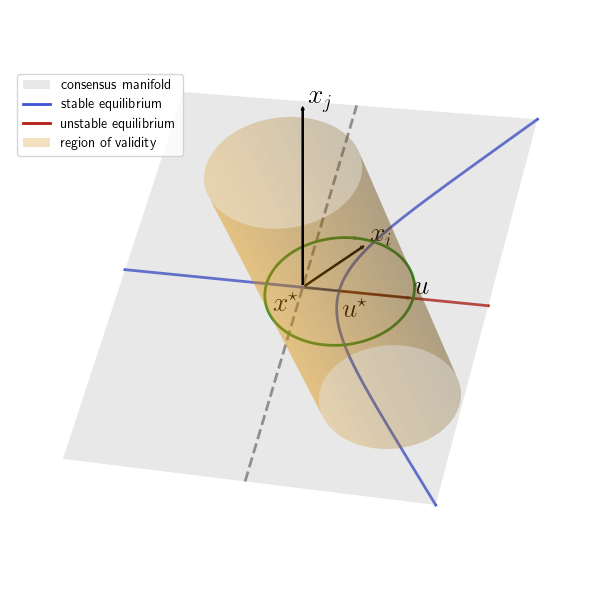

In [5]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot([0, 0], [-xlim, xlim], [-xlim, xlim], color="black", alpha=0.5, lw=2, ls="--")
# ax.plot([0, 0], [-2*xlim, 2*xlim], [0, 0], color="black", alpha=0.5, lw=2, ls="--")
# ax.plot([0, 0], [0, 0], [-1.5*xlim, 1.5*xlim], color="black", alpha=0.5, lw=2, ls="--")

ax.plot_surface(U, Xi, Xj, alpha=0.3, color="#cacaca", label="consensus manifold")
ax.plot([-ulim, 1], [0, 0], [0, 0], color="#4053d3", lw=2, label="stable equilibrium")
ax.plot([1, ulim], [0, 0], [0, 0], color="#b51d14", lw=2, label="unstable equilibrium")
ax.plot(us, +prong, +prong, color="#4053d3", lw=2)
ax.plot(us, -prong, -prong, color="#4053d3", lw=2)

ax.text(-.6,-.7,-.7, r"$x^\star$", fontsize=20, color="black")
ax.text(1.2,-.4,-.1, r"$u^\star$", fontsize=20, color="black", va="top", ha="left")

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.pane.set_visible(False)
    axis.line.set_color((0, 0, 0, 0))
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set(xlim=(-ulim, ulim), ylim=(-xlim, xlim), zlim=(-xlim, xlim))

ax.arrow3D(0,0,0, 3,0,0, mutation_scale=4, ec="black", fc="black", alpha=0.3)
ax.text(3.0,0.1,0.1, r"$u$", fontsize=20)
ax.arrow3D(0,0,0, 0,6,0, mutation_scale=4, ec="black", fc="black", alpha=1.0)
ax.text(0.1,6.0,0.1, r"$x_i$", fontsize=20)
ax.arrow3D(0,0,0, 0,0,6, mutation_scale=4, ec="black", fc="black", alpha=1.0)
ax.text(0.1,0.1,6.0, r"$x_j$", fontsize=20)

ax.plot_surface(X,Y,Z, alpha=0.25, color="orange", shade=True, label="region of validity")
ax.plot(circle[0], circle[1], circle[2], color="green", lw=2)

ax.legend(loc='upper left', bbox_to_anchor=(0,.9))
ax.view_init(elev=15, azim=-69, roll=0)
ax.set_box_aspect([1.25, 1, 1])

plt.tight_layout()
plt.savefig("../images/bounds.png", bbox_inches="tight", dpi=600)
plt.show()